# Tests on synthetic models constructed by Gail to assess how to include more metal-poor stars in the targetting strategy of HGE

In [1]:
# load in the correct modules
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import cmasher as cm
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
from matplotlib.colors import LogNorm

In [2]:
# LOAD THE DATA
path = '/Users/dhortad/Projects/HGE/data/combined_hge_gums_marshall.fits'
tb = fits.open(path)
data = tb[1].data 
print(len(data))

625349


In [3]:
# limit to only the fields that HGE will target
mask_b = np.abs(data['b'])<3.
len(data[mask_b])

434155

Text(0.5, 0, 'distance [kpc]')

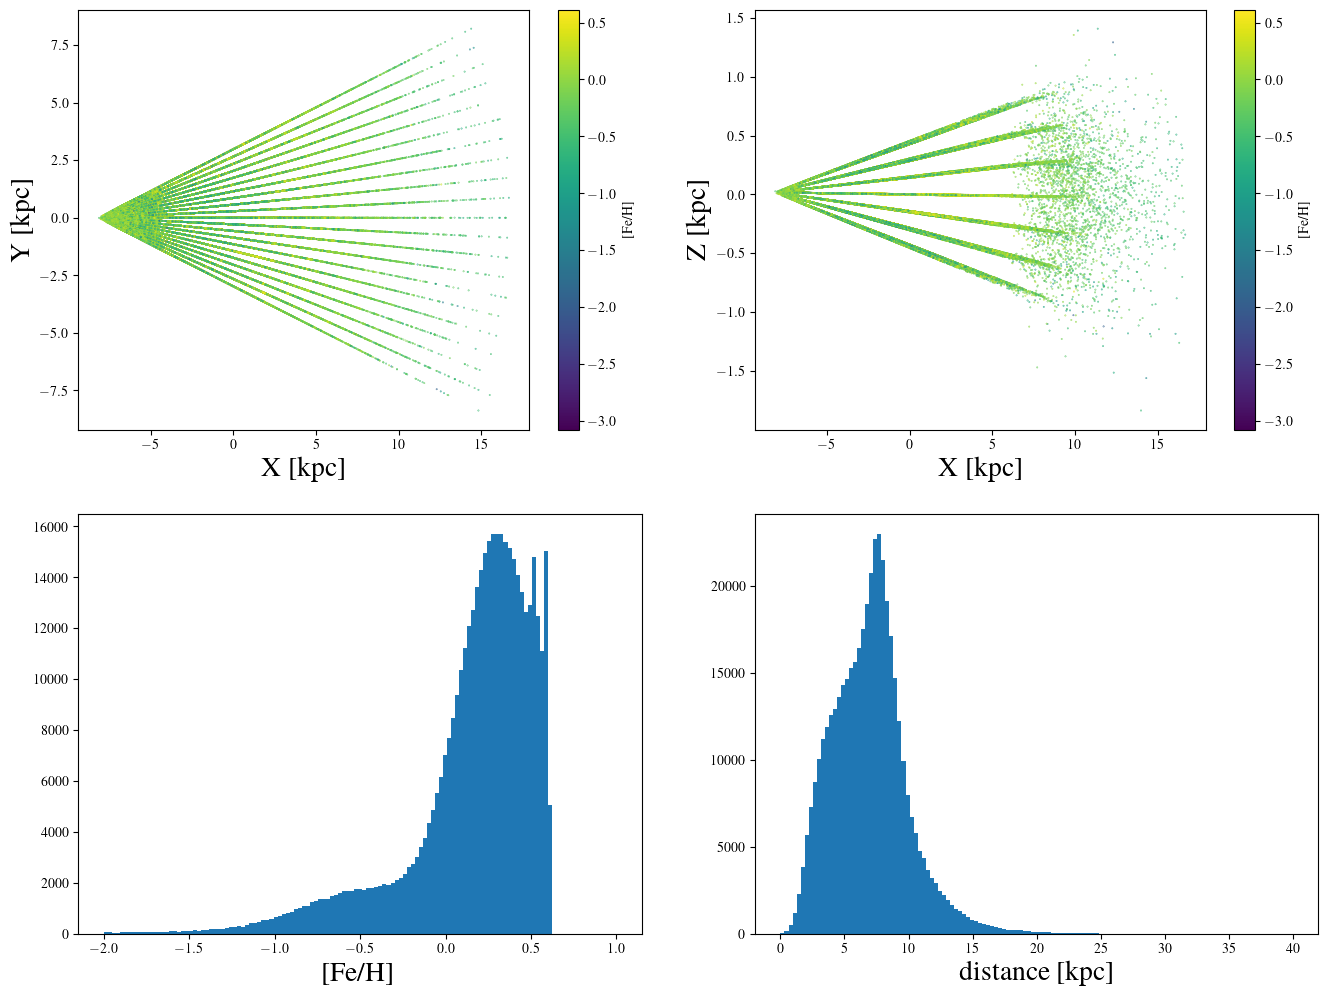

In [7]:
# what does the parent sample look like?
plt.figure(figsize=(16,12))

plt.subplot(2,2,1)
plt.scatter(data['x'][mask_b], data['y'][mask_b], s=0.1, c=data['FE_H_evolved'][mask_b])
plt.xlabel('X [kpc]', fontsize=20)
plt.ylabel('Y [kpc]', fontsize=20)
plt.colorbar(label='[Fe/H]')

plt.subplot(2,2,2)
plt.scatter(data['x'][mask_b], data['z'][mask_b], s=0.1, c=data['FE_H_evolved'][mask_b])
plt.xlabel('X [kpc]', fontsize=20)
plt.ylabel('Z [kpc]', fontsize=20)
plt.colorbar(label='[Fe/H]')

plt.subplot(2,2,3)
plt.hist(data['FE_H_evolved'][mask_b],np.linspace(-2,1,128))
plt.xlabel('[Fe/H]', fontsize=20)

plt.subplot(2,2,4)
plt.hist(data['Dist'][mask_b],np.linspace(0,40,128))
plt.xlabel('distance [kpc]', fontsize=20)


Text(0, 0.5, '(H-K)')

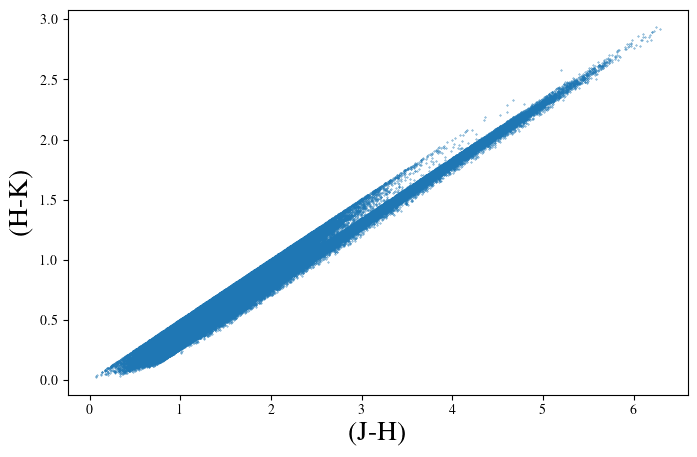

In [28]:
# plot (J-H) vs (H-Ks) to get the slope that you will use for the Q param

plt.figure(figsize=(8,5))
plt.scatter(data['2MASS_J'][mask_b]- data['2MASS_H'][mask_b], data['2MASS_H'][mask_b] - data['2MASS_Ks'][mask_b], s=0.1)
plt.xlabel('(J-H)', fontsize=20)
plt.ylabel('(H-K)', fontsize=20)
# plt.ylim(18,6)

In [38]:
#  fit the slope

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(data['2MASS_H'][mask_b] - data['2MASS_Ks'][mask_b], data['2MASS_J'][mask_b]- data['2MASS_H'][mask_b])

print(f"Calculated k: {slope:.4f}")
print(f"Calculated intercept: {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}") # Should be very close to 1.0 for synthetic data


Calculated k: 2.0512
Calculated intercept: 0.2595
R-squared: 0.9840


Define dereddened colours and the Q parameter.

The Q parameter is a "reddening-free index" that is a clever way to combine magnitudes so that the effects of interstellar extinction cancel out. This allows you to see the "true" intrinsic color of a star even if it’s buried behind clouds of dust. It is defined as
$Q = (J - H) - \left( \frac{E(J - H)}{E(H - K_s)} \right) \times (H - K_s)$,

Since the slope of the $(J-H) vs (H-K_s)$ returned a value of 2.05, we will use this to get Q, such that: $Q = (J - H) - 2.05 \times (H - K_s)$

In [44]:
Habs = data['2MASS_H'] - (5.*np.log10(data['Dist']*1e3)) +5.
Q_param = (data['2MASS_J'] - data['2MASS_H']) - slope*(data['2MASS_H'] - data['2MASS_Ks']) 
J0 = data['2MASS_J'] - (2.5 * data['A_Ks'])
H_0 = data['2MASS_H'] - (1.55 * data['A_Ks'])
Ks_0 = data['2MASS_Ks'] - data['A_Ks']


Text(0, 0.5, '$A_{K_s}$')

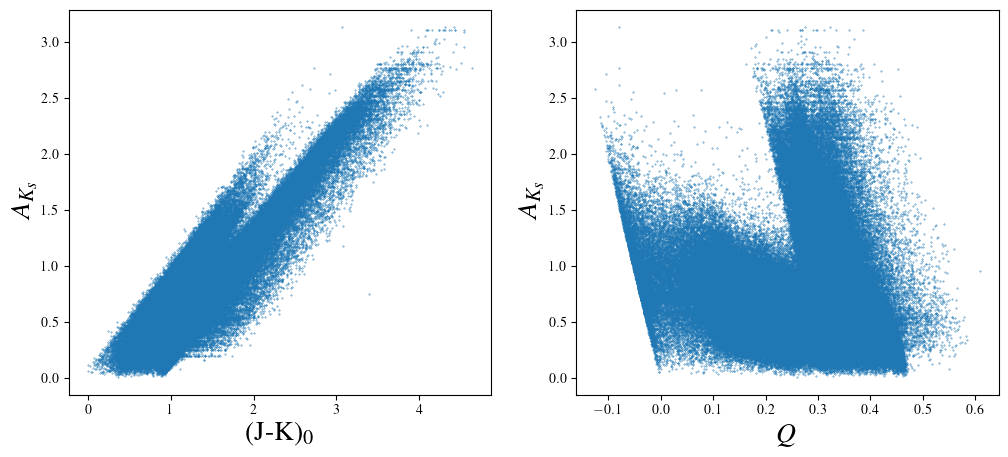

In [45]:
# see how extinction varies with J_0-Ks_0 and Q

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(J0[mask_b]- Ks_0[mask_b], data['A_Ks'][mask_b], s=0.1)
plt.xlabel('(J-K)$_0$', fontsize=20)
plt.ylabel('$A_{K_s}$', fontsize=20)
# plt.ylim(18,6)

plt.subplot(1,2,2)
plt.scatter(Q_param[mask_b], data['A_Ks'][mask_b], s=0.1)
plt.xlabel('$Q$', fontsize=20)
plt.ylabel('$A_{K_s}$', fontsize=20)
# plt.ylim(18.2,6)


Not perfect, but will do for now!

Compare how distance and metallicity appear for H band mag vs dereddened ($J-K_s$) and Q param

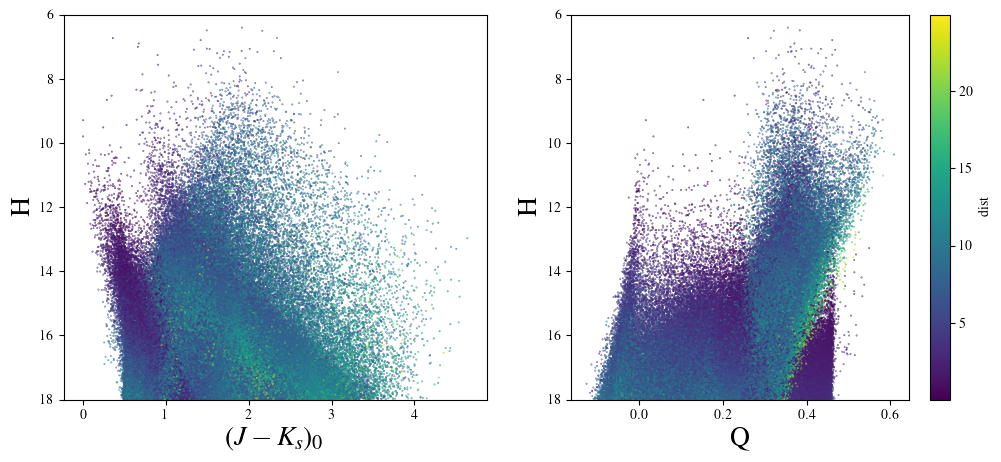

In [46]:
# distance

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(J0[mask_b]- Ks_0[mask_b], data['2MASS_H'][mask_b], s=0.1, c=data['dist'][mask_b])
plt.xlabel(r'($J-K_s$)$_0$', fontsize=20)
plt.ylabel('H', fontsize=20)
plt.ylim(18,6)

plt.subplot(1,2,2)
plt.scatter(Q_param[mask_b], data['2MASS_H'][mask_b], s=0.1, c=data['dist'][mask_b])
plt.xlabel('Q', fontsize=20)
plt.ylabel('H', fontsize=20)
plt.ylim(18,6)
plt.colorbar(label='dist')

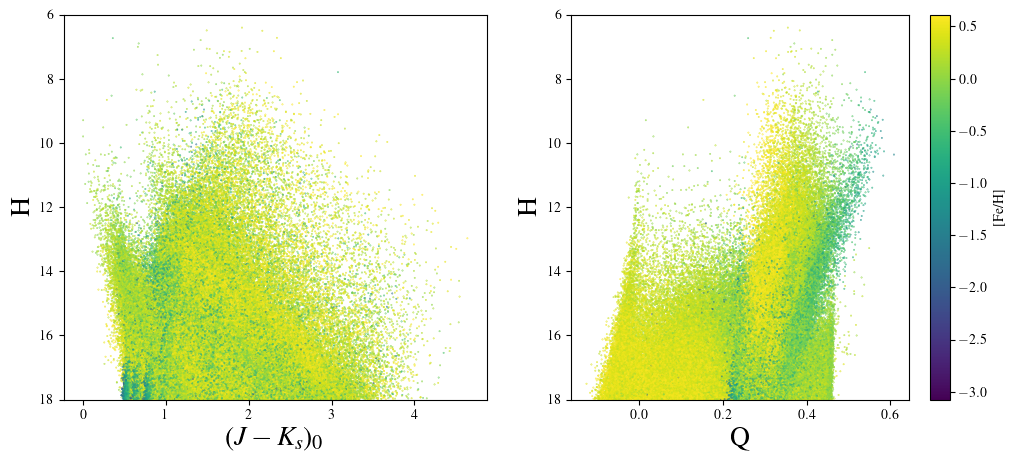

In [47]:
# metallicity

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(J0[mask_b]- Ks_0[mask_b], data['2MASS_H'][mask_b], s=0.1, c=data['FE_H_evolved'][mask_b])
plt.xlabel(r'($J-K_s$)$_0$', fontsize=20)
plt.ylabel('H', fontsize=20)
plt.ylim(18,6)

plt.subplot(1,2,2)
plt.scatter(Q_param[mask_b], data['2MASS_H'][mask_b], s=0.1, c=data['FE_H_evolved'][mask_b])
plt.xlabel('Q', fontsize=20)
plt.ylabel('H', fontsize=20)
plt.ylim(18,6)
plt.colorbar(label='[Fe/H]')

now do the same for metal-poor stars ([Fe/H]<-1)

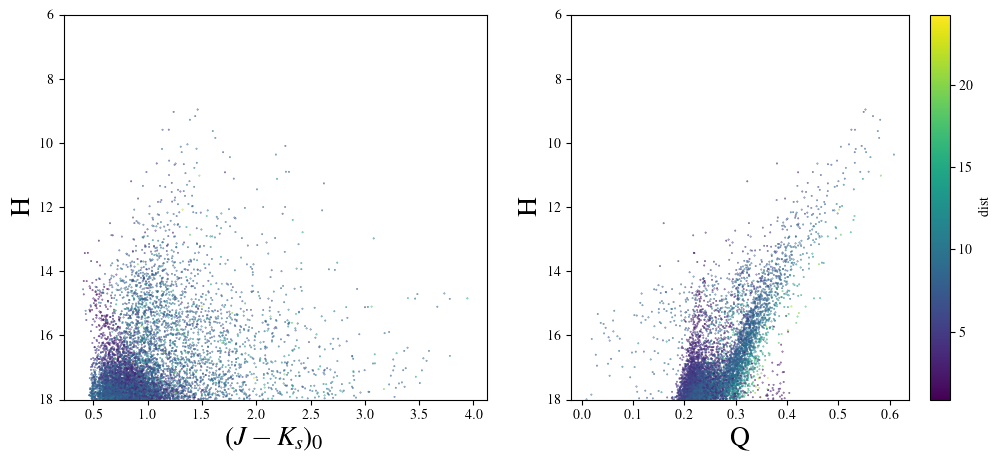

In [50]:
# distance

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(J0[mask_b&(data['FE_H_evolved']<-1)]- Ks_0[mask_b&(data['FE_H_evolved']<-1)], data['2MASS_H'][mask_b&(data['FE_H_evolved']<-1)], s=0.1, c=data['dist'][mask_b&(data['FE_H_evolved']<-1)])
plt.xlabel(r'($J-K_s$)$_0$', fontsize=20)
plt.ylabel('H', fontsize=20)
plt.ylim(18,6)

plt.subplot(1,2,2)
plt.scatter(Q_param[mask_b&(data['FE_H_evolved']<-1)], data['2MASS_H'][mask_b&(data['FE_H_evolved']<-1)], s=0.1, c=data['dist'][mask_b&(data['FE_H_evolved']<-1)])
plt.xlabel('Q', fontsize=20)
plt.ylabel('H', fontsize=20)
plt.ylim(18,6)
plt.colorbar(label='dist')

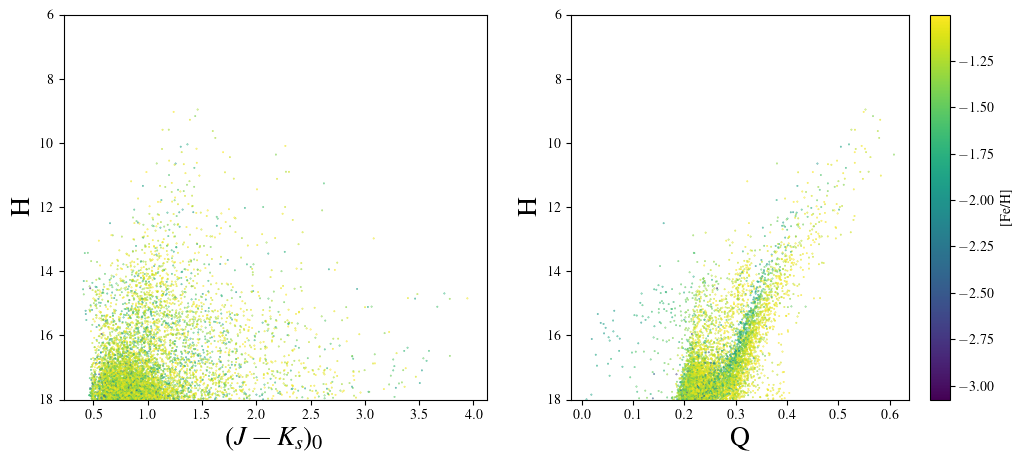

In [51]:
# distance

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(J0[mask_b&(data['FE_H_evolved']<-1)]- Ks_0[mask_b&(data['FE_H_evolved']<-1)], data['2MASS_H'][mask_b&(data['FE_H_evolved']<-1)], s=0.1, c=data['FE_H_evolved'][mask_b&(data['FE_H_evolved']<-1)])
plt.xlabel(r'($J-K_s$)$_0$', fontsize=20)
plt.ylabel('H', fontsize=20)
plt.ylim(18,6)

plt.subplot(1,2,2)
plt.scatter(Q_param[mask_b&(data['FE_H_evolved']<-1)], data['2MASS_H'][mask_b&(data['FE_H_evolved']<-1)], s=0.1, c=data['FE_H_evolved'][mask_b&(data['FE_H_evolved']<-1)])
plt.xlabel('Q', fontsize=20)
plt.ylabel('H', fontsize=20)
plt.ylim(18,6)
plt.colorbar(label='[Fe/H]')


Given the plots above, let's compare the fraction of metal-poor and distant stars for samples defined using ($J-K_s$)$_{0}$ or the Q parameter

For H<15 mag

In [86]:
hge_cut = (data['2MASS_H']<15)&((J0-Ks_0)>0.9)
mycut = (data['2MASS_H']<15)&(Q_param>0.3)
mask_fe = data['FE_H_evolved']<-1
mask_rad = data['dist']>8.275

print('There are '+str(len(data[mask_b&hge_cut]))+' stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut]))+' stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_fe]))+' metal-poor stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_fe]))+' metal-poor stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_rad]))+' far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_rad]))+' far side of the Galaxy stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_fe&mask_rad]))+' metal-poor far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_fe&mask_rad]))+' metal-poor far side of the Galaxy stars using the Q-parameter cut in the full sample')

print('The percentage of metal-poor stars using the ($J-K_s$)$_{0}$ cut is '+str(len(data[mask_b&hge_cut&mask_fe])/len(data[mask_b&hge_cut])*100))
print('The percentage of metal-poor stars using the Q-parameter cut is '+str(len(data[mask_b&mycut&mask_fe])/len(data[mask_b&mycut])*100))

print('The percentage of far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut is '+str(len(data[mask_b&hge_cut&mask_rad])/len(data[mask_b&hge_cut])*100))
print('The percentage of far side of the Galaxy stars using the Q-parameter cut is '+str(len(data[mask_b&mycut&mask_rad])/len(data[mask_b&mycut])*100))


There are 47533 stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 45476 stars using the Q-parameter cut in the full sample
There are 583 metal-poor stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 610 metal-poor stars using the Q-parameter cut in the full sample
There are 20298 far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 19592 far side of the Galaxy stars using the Q-parameter cut in the full sample
There are 279 metal-poor far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 301 metal-poor far side of the Galaxy stars using the Q-parameter cut in the full sample
The percentage of metal-poor stars using the ($J-K_s$)$_{0}$ cut is 1.2265163149811709
The percentage of metal-poor stars using the Q-parameter cut is 1.341366874835078
The percentage of far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut is 42.702964256411335
The percentage of far side of the Galaxy stars using

For H<14.5

In [87]:
hge_cut = (data['2MASS_H']<14.5)&((J0-Ks_0)>0.9)
mycut = (data['2MASS_H']<14.5)&(Q_param>0.3)
mask_fe = data['FE_H_evolved']<-1
mask_rad = data['dist']>8.275

print('There are '+str(len(data[mask_b&hge_cut]))+' stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut]))+' stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_fe]))+' metal-poor stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_fe]))+' metal-poor stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_rad]))+' far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_rad]))+' far side of the Galaxy stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_fe&mask_rad]))+' metal-poor far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_fe&mask_rad]))+' metal-poor far side of the Galaxy stars using the Q-parameter cut in the full sample')

print('The percentage of metal-poor stars using the ($J-K_s$)$_{0}$ cut is '+str(len(data[mask_b&hge_cut&mask_fe])/len(data[mask_b&hge_cut])*100))
print('The percentage of metal-poor stars using the Q-parameter cut is '+str(len(data[mask_b&mycut&mask_fe])/len(data[mask_b&mycut])*100))

print('The percentage of far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut is '+str(len(data[mask_b&hge_cut&mask_rad])/len(data[mask_b&hge_cut])*100))
print('The percentage of far side of the Galaxy stars using the Q-parameter cut is '+str(len(data[mask_b&mycut&mask_rad])/len(data[mask_b&mycut])*100))


There are 34586 stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 33530 stars using the Q-parameter cut in the full sample
There are 411 metal-poor stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 445 metal-poor stars using the Q-parameter cut in the full sample
There are 13199 far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 12837 far side of the Galaxy stars using the Q-parameter cut in the full sample
There are 186 metal-poor far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 205 metal-poor far side of the Galaxy stars using the Q-parameter cut in the full sample
The percentage of metal-poor stars using the ($J-K_s$)$_{0}$ cut is 1.1883421037413984
The percentage of metal-poor stars using the Q-parameter cut is 1.3271696987772146
The percentage of far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut is 38.162840455675706
The percentage of far side of the Galaxy stars usin

For H<14

In [88]:
hge_cut = (data['2MASS_H']<14.)&((J0-Ks_0)>0.9)
mycut = (data['2MASS_H']<14.)&(Q_param>0.3)
mask_fe = data['FE_H_evolved']<-1
mask_rad = data['dist']>8.275

print('There are '+str(len(data[mask_b&hge_cut]))+' stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut]))+' stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_fe]))+' metal-poor stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_fe]))+' metal-poor stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_rad]))+' far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_rad]))+' far side of the Galaxy stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_fe&mask_rad]))+' metal-poor far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_fe&mask_rad]))+' metal-poor far side of the Galaxy stars using the Q-parameter cut in the full sample')

print('The percentage of metal-poor stars using the ($J-K_s$)$_{0}$ cut is '+str(len(data[mask_b&hge_cut&mask_fe])/len(data[mask_b&hge_cut])*100))
print('The percentage of metal-poor stars using the Q-parameter cut is '+str(len(data[mask_b&mycut&mask_fe])/len(data[mask_b&mycut])*100))

print('The percentage of far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut is '+str(len(data[mask_b&hge_cut&mask_rad])/len(data[mask_b&hge_cut])*100))
print('The percentage of far side of the Galaxy stars using the Q-parameter cut is '+str(len(data[mask_b&mycut&mask_rad])/len(data[mask_b&mycut])*100))


There are 23240 stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 22699 stars using the Q-parameter cut in the full sample
There are 279 metal-poor stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 302 metal-poor stars using the Q-parameter cut in the full sample
There are 7684 far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 7386 far side of the Galaxy stars using the Q-parameter cut in the full sample
There are 128 metal-poor far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 137 metal-poor far side of the Galaxy stars using the Q-parameter cut in the full sample
The percentage of metal-poor stars using the ($J-K_s$)$_{0}$ cut is 1.2005163511187606
The percentage of metal-poor stars using the Q-parameter cut is 1.3304550861271423
The percentage of far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut is 33.063683304647164
The percentage of far side of the Galaxy stars using 

For H<13.5

In [89]:
hge_cut = (data['2MASS_H']<13.5)&((J0-Ks_0)>0.9)
mycut = (data['2MASS_H']<13.5)&(Q_param>0.3)
mask_fe = data['FE_H_evolved']<-1
mask_rad = data['dist']>8.275

print('There are '+str(len(data[mask_b&hge_cut]))+' stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut]))+' stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_fe]))+' metal-poor stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_fe]))+' metal-poor stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_rad]))+' far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_rad]))+' far side of the Galaxy stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_fe&mask_rad]))+' metal-poor far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_fe&mask_rad]))+' metal-poor far side of the Galaxy stars using the Q-parameter cut in the full sample')

print('The percentage of metal-poor stars using the ($J-K_s$)$_{0}$ cut is '+str(len(data[mask_b&hge_cut&mask_fe])/len(data[mask_b&hge_cut])*100))
print('The percentage of metal-poor stars using the Q-parameter cut is '+str(len(data[mask_b&mycut&mask_fe])/len(data[mask_b&mycut])*100))

print('The percentage of far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut is '+str(len(data[mask_b&hge_cut&mask_rad])/len(data[mask_b&hge_cut])*100))
print('The percentage of far side of the Galaxy stars using the Q-parameter cut is '+str(len(data[mask_b&mycut&mask_rad])/len(data[mask_b&mycut])*100))


There are 14917 stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 14639 stars using the Q-parameter cut in the full sample
There are 190 metal-poor stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 200 metal-poor stars using the Q-parameter cut in the full sample
There are 4842 far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 4591 far side of the Galaxy stars using the Q-parameter cut in the full sample
There are 91 metal-poor far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 93 metal-poor far side of the Galaxy stars using the Q-parameter cut in the full sample
The percentage of metal-poor stars using the ($J-K_s$)$_{0}$ cut is 1.273714553864718
The percentage of metal-poor stars using the Q-parameter cut is 1.3662135391761734
The percentage of far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut is 32.459609841120866
The percentage of far side of the Galaxy stars using the

For H<13

In [90]:
hge_cut = (data['2MASS_H']<13.)&((J0-Ks_0)>0.9)
mycut = (data['2MASS_H']<13.)&(Q_param>0.3)
mask_fe = data['FE_H_evolved']<-1
mask_rad = data['dist']>8.275

print('There are '+str(len(data[mask_b&hge_cut]))+' stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut]))+' stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_fe]))+' metal-poor stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_fe]))+' metal-poor stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_rad]))+' far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_rad]))+' far side of the Galaxy stars using the Q-parameter cut in the full sample')

print('There are '+str(len(data[mask_b&hge_cut&mask_fe&mask_rad]))+' metal-poor far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample')
print('There are '+str(len(data[mask_b&mycut&mask_fe&mask_rad]))+' metal-poor far side of the Galaxy stars using the Q-parameter cut in the full sample')

print('The percentage of metal-poor stars using the ($J-K_s$)$_{0}$ cut is '+str(len(data[mask_b&hge_cut&mask_fe])/len(data[mask_b&hge_cut])*100))
print('The percentage of metal-poor stars using the Q-parameter cut is '+str(len(data[mask_b&mycut&mask_fe])/len(data[mask_b&mycut])*100))

print('The percentage of far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut is '+str(len(data[mask_b&hge_cut&mask_rad])/len(data[mask_b&hge_cut])*100))
print('The percentage of far side of the Galaxy stars using the Q-parameter cut is '+str(len(data[mask_b&mycut&mask_rad])/len(data[mask_b&mycut])*100))


There are 9876 stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 9736 stars using the Q-parameter cut in the full sample
There are 135 metal-poor stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 141 metal-poor stars using the Q-parameter cut in the full sample
There are 3374 far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 3180 far side of the Galaxy stars using the Q-parameter cut in the full sample
There are 64 metal-poor far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut in the full sample
There are 66 metal-poor far side of the Galaxy stars using the Q-parameter cut in the full sample
The percentage of metal-poor stars using the ($J-K_s$)$_{0}$ cut is 1.3669501822600243
The percentage of metal-poor stars using the Q-parameter cut is 1.4482333607230895
The percentage of far side of the Galaxy stars using the ($J-K_s$)$_{0}$ cut is 34.163628999594984
The percentage of far side of the Galaxy stars using the 

# Summary

Overall, the Q-parameter does a bit of a better job at picking out more metal-poor stars, this is especially the case at lower magnitude. However, in some brighter magnitude cuts, it picks out less distant stars. 